# Milestone 3: Unified Landmark Extraction

**Project:** A Lightweight Multi-Modal Driver Distraction Detection System Using MobileViT and MediaPipe with Explainable AI and Personalized Audio Feedback

**Objective:** Extract high-dimensional geometric features (Face Mesh, Head Pose, EAR, Gaze, and Hand Landmarks) from the State Farm Distracted Driver dataset to support multi-modal fusion in subsequent milestones.

In [1]:
!pip install -q mediapipe opencv-python-headless numpy pandas tqdm matplotlib pyarrow

In [2]:
import os
import cv2
import json
import time
import numpy as np
import pandas as pd
import mediapipe as mp
import urllib.request
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from typing import Tuple, List, Dict, Any, Optional
from google.colab import drive

# MediaPipe Tasks API
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [3]:
class Config:
    DRIVE_MOUNT = Path('/content/drive')
    DATASET_ZIP = DRIVE_MOUNT / 'MyDrive/RI/Dataset/state-farm-distracted-driver-detection.zip'
    EXTRACT_DIR = Path('/content/dataset')
    OUTPUT_DIR = Path('/content/outputs/landmarks')
    MODEL_DIR = Path('/content/models')

    # Extraction Parameters
    MIN_DETECTION_CONFIDENCE = 0.5
    SAMPLE_SIZE = 500  # Set to None for full dataset processing

# Create directories
Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
Config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

def download_mediapipe_models():
    urls = {
        "face": "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        "hand": "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    }
    paths = {}
    for key, url in urls.items():
        path = Config.MODEL_DIR / f"{key}_landmarker.task"
        if not path.exists():
            print(f"Downloading {key} model...")
            urllib.request.urlretrieve(url, path)
        paths[key] = path
    return paths

MODEL_PATHS = download_mediapipe_models()

In [4]:
if not Config.DRIVE_MOUNT.exists():
    drive.mount(str(Config.DRIVE_MOUNT))

if not Config.EXTRACT_DIR.exists():
    print("Extracting dataset...")
    !unzip -q "{Config.DATASET_ZIP}" -d "{Config.EXTRACT_DIR}"

In [5]:
csv_matches = list(Config.EXTRACT_DIR.rglob('driver_imgs_list.csv'))
if not csv_matches:
    raise FileNotFoundError("driver_imgs_list.csv not found in extraction directory.")

csv_path = csv_matches[0]
img_root = csv_path.parent / 'imgs' / 'train'
df_meta = pd.read_csv(csv_path)

print(f"Located CSV at: {csv_path}")
print(f"Image root: {img_root}")

Located CSV at: /content/dataset/driver_imgs_list.csv
Image root: /content/dataset/imgs/train


In [6]:
print(f"--- Dataset Verification ---")
print(f"Total Images: {len(df_meta)}")
print(f"Unique Drivers (Subjects): {df_meta['subject'].nunique()}")
print(f"Classes: {df_meta['classname'].nunique()} ({sorted(df_meta['classname'].unique())})")

--- Dataset Verification ---
Total Images: 22424
Unique Drivers (Subjects): 26
Classes: 10 (['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9'])


In [7]:
class UnifiedDriverExtractor:
    def __init__(self):
        base_options = lambda p: python.BaseOptions(model_asset_path=str(p))
        self.face_landmarker = vision.FaceLandmarker.create_from_options(
            vision.FaceLandmarkerOptions(
                base_options=base_options(MODEL_PATHS['face']),
                running_mode=vision.RunningMode.IMAGE,
                output_face_blendshapes=True,
                min_face_detection_confidence=Config.MIN_DETECTION_CONFIDENCE))

        self.hand_landmarker = vision.HandLandmarker.create_from_options(
            vision.HandLandmarkerOptions(
                base_options=base_options(MODEL_PATHS['hand']),
                running_mode=vision.RunningMode.IMAGE,
                num_hands=2,
                min_hand_detection_confidence=Config.MIN_DETECTION_CONFIDENCE))

    def _calculate_ear(self, lms, indices):
        try:
            pts = [np.array([lms[i].x, lms[i].y]) for i in indices]
            v1 = np.linalg.norm(pts[1] - pts[5])
            v2 = np.linalg.norm(pts[2] - pts[4])
            h = np.linalg.norm(pts[0] - pts[3])
            return (v1 + v2) / (2.0 * h + 1e-6)
        except: return 0.0

    def _estimate_pose_gaze(self, lms, w, h):
        # 3D model points (standard face model)
        model_pts = np.array([(0,0,0),(0,-330,-65),(-225,170,-135),(225,170,-135),(-150,-150,-125),(150,-150,-125)])
        indices = [1, 152, 33, 263, 61, 291]
        try:
            img_pts = np.array([(lms[i].x * w, lms[i].y * h) for i in indices], dtype="double")
            cam_mat = np.array([[w, 0, w/2], [0, w, h/2], [0, 0, 1]], dtype="double")
            success, rvec, tvec = cv2.solvePnP(model_pts, img_pts, cam_mat, np.zeros((4,1)))
            if not success:
                return {"pitch":0.0, "yaw":0.0, "roll":0.0, "gaze_x":0.0, "gaze_y":0.0}
            rmat, _ = cv2.Rodrigues(rvec)
            angles = cv2.decomposeProjectionMatrix(np.hstack((rmat, tvec)))[0]
            return {"pitch": angles[0][0], "yaw": angles[1][0], "roll": angles[2][0], "gaze_x": lms[4].x, "gaze_y": lms[4].y}
        except Exception as e:
            return {"pitch":0.0, "yaw":0.0, "roll":0.0, "gaze_x":0.0, "gaze_y":0.0}

    def process_image(self, path: Path) -> Dict[str, Any]:
        img = cv2.imread(str(path))
        if img is None: return {}
        h, w, _ = img.shape
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        res = {"face_detected": 0, "left_hand_detected": 0, "right_hand_detected": 0}
        face_result = self.face_landmarker.detect(mp_img)
        if face_result.face_landmarks:
            res["face_detected"] = 1
            lms = face_result.face_landmarks[0]
            xs, ys = [l.x for l in lms], [l.y for l in lms]
            res.update({"face_xmin": min(xs), "face_ymin": min(ys), "face_width": max(xs)-min(xs), "face_height": max(ys)-min(ys)})
            res.update(self._estimate_pose_gaze(lms, w, h))
            res["ear_left"] = self._calculate_ear(lms, [33, 160, 158, 133, 153, 144])
            res["ear_right"] = self._calculate_ear(lms, [362, 385, 387, 263, 373, 380])
            res["ear_avg"] = (res["ear_left"] + res["ear_right"]) / 2.0
            res["eye_open_left"] = face_result.face_blendshapes[0][9].score if face_result.face_blendshapes else 1.0
            res["eye_open_right"] = face_result.face_blendshapes[0][10].score if face_result.face_blendshapes else 1.0
            res["face_lms"] = [c for l in lms for c in (l.x, l.y, l.z)]
        else:
            res.update({k: 0.0 for k in ["face_xmin", "face_ymin", "face_width", "face_height", "pitch", "yaw", "roll", "ear_left", "ear_right", "ear_avg", "eye_open_left", "eye_open_right", "gaze_x", "gaze_y"]})
            res["face_lms"] = [0.0] * 1434

        hand_result = self.hand_landmarker.detect(mp_img)
        l_flat, r_flat = [0.0]*63, [0.0]*63
        if hand_result.hand_landmarks:
            for i, hlms in enumerate(hand_result.hand_landmarks):
                lbl = hand_result.handedness[i][0].category_name
                flat = [c for l in hlms for c in (l.x, l.y, l.z)]
                if lbl == 'Left': res["left_hand_detected"], l_flat = 1, flat
                else: res["right_hand_detected"], r_flat = 1, flat
        res.update({"left_hand_lms": l_flat, "right_hand_lms": r_flat})
        return res

In [8]:
extractor = UnifiedDriverExtractor()
working_df = df_meta.sample(Config.SAMPLE_SIZE, random_state=42) if Config.SAMPLE_SIZE else df_meta
results = []
start_time = time.time()

for _, row in tqdm(working_df.iterrows(), total=len(working_df), desc="Processing"):
    img_p = img_root / row['classname'] / row['img']
    feat = extractor.process_image(img_p)
    if feat:
        feat.update({"image_name": row['img'], "class_label": row['classname'], "subject": row['subject']})
        results.append(feat)

elapsed_time = time.time() - start_time
final_df = pd.DataFrame(results)

Processing:   0%|          | 0/500 [00:00<?, ?it/s]

In [9]:
import json
# Ensure output directory exists
Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Reference the existing final_df and elapsed_time from the kernel
if 'final_df' in globals() and not final_df.empty:
    # Save extracted features
    final_df.to_csv(Config.OUTPUT_DIR / 'landmarks.csv', index=False)
    final_df.to_parquet(Config.OUTPUT_DIR / 'landmarks.parquet', index=False)
    final_df[['image_name', 'class_label', 'subject']].to_csv(Config.OUTPUT_DIR / 'metadata.csv', index=False)

    # Generate statistics
    # Note: Using elapsed_time from the extraction cell
    stats_dict = {
        "face_detection_rate": float(final_df['face_detected'].mean() * 100),
        "hands_detection_rate": float(((final_df['left_hand_detected'] == 1) | (final_df['right_hand_detected'] == 1)).mean() * 100),
        "avg_ms_per_image": float((elapsed_time / len(final_df)) * 1000),
        "fps": float(len(final_df) / elapsed_time)
    }

    # Save metadata JSON files
    with open(Config.OUTPUT_DIR / 'landmark_statistics.json', 'w') as f:
        json.dump(stats_dict, f, indent=4)
    with open(Config.OUTPUT_DIR / 'processing_summary.json', 'w') as f:
        json.dump({"status": "Completed", "total": len(final_df), "time": elapsed_time}, f, indent=4)

    print(f"Successfully saved {len(final_df)} records to {Config.OUTPUT_DIR}")
else:
    print("Error: final_df is not available.")

Successfully saved 500 records to /content/outputs/landmarks


In [10]:
# Reference statistics directly from the previous processing step
print("--- Milestone 3: Extraction Statistics ---")
if 'stats_dict' in globals():
    for k, v in stats_dict.items():
        print(f"{k.replace('_', ' ').title()}: {v:.2f}")
else:
    print("Statistics dictionary not found. Please ensure cell f52f7b50 executed correctly.")

--- Milestone 3: Extraction Statistics ---
Face Detection Rate: 32.60
Hands Detection Rate: 82.20
Avg Ms Per Image: 85.45
Fps: 11.70


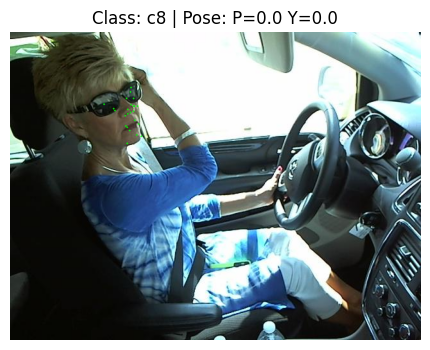

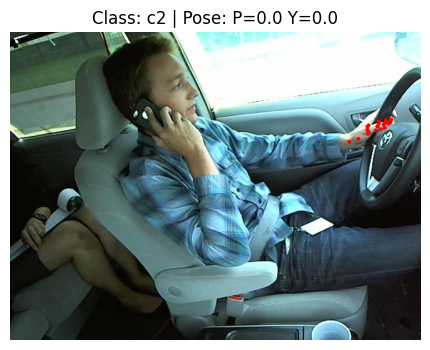

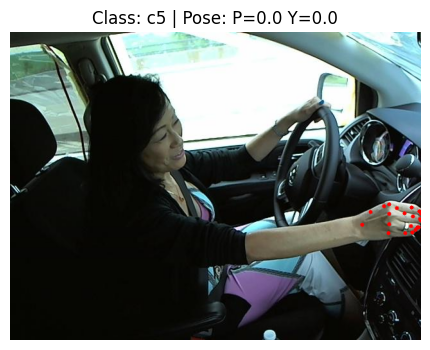

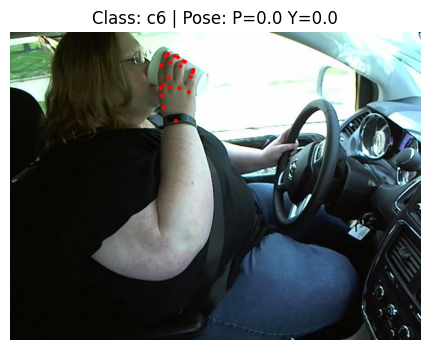

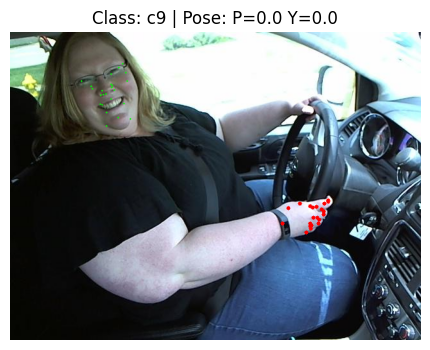

In [11]:
def visualize_sample(df, n=5):
    samples = df.sample(min(n, len(df)))
    for _, row in samples.iterrows():
        p = img_root / row['class_label'] / row['image_name']
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        # Face mesh visualization
        if row['face_detected']:
            lms = np.array(row['face_lms']).reshape(-1, 3)
            for i in range(0, 478, 20):
                cv2.circle(img, (int(lms[i][0]*w), int(lms[i][1]*h)), 1, (0, 255, 0), -1)

        # Hands visualization
        for side in ['left', 'right']:
            if row[f'{side}_hand_detected']:
                hlms = np.array(row[f'{side}_hand_lms']).reshape(-1, 3)
                for pt in hlms:
                    cv2.circle(img, (int(pt[0]*w), int(pt[1]*h)), 3, (255, 0, 0), -1)

        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"Class: {row['class_label']} | Pose: P={row['pitch']:.1f} Y={row['yaw']:.1f}")
        plt.axis('off')
        plt.show()

visualize_sample(final_df)

In [12]:
import pandas as pd
from IPython.display import display

required_files = ['landmarks.csv', 'landmarks.parquet', 'metadata.csv', 'landmark_statistics.json', 'processing_summary.json']
missing_files = [f for f in required_files if not (Config.OUTPUT_DIR / f).exists()]

if not missing_files:
    print(f"Validation Successful: All {len(required_files)} files generated.")
    print(f"Final DataFrame Shape: {final_df.shape}")
    print(f"Feature Columns (First 10): {final_df.columns.tolist()[:10]}")

    # Display first few rows to verify coordinate normalization and metadata alignment
    display(final_df.head())

    print("\n--- Milestone 3: Landmark Extraction Completed Successfully ---")
    print("Ready for Milestone 4: Model Training and Multi-Modal Fusion.")
else:
    print(f"Validation Failed. The following files are missing: {missing_files}")

Validation Successful: All 5 files generated.
Final DataFrame Shape: (500, 23)
Feature Columns (First 10): ['face_detected', 'left_hand_detected', 'right_hand_detected', 'face_xmin', 'face_ymin', 'face_width', 'face_height', 'pitch', 'yaw', 'roll']


,face_detected,left_hand_detected,right_hand_detected,face_xmin,face_ymin,face_width,face_height,pitch,yaw,roll,...,eye_open_left,eye_open_right,gaze_x,gaze_y,face_lms,left_hand_lms,right_hand_lms,image_name,class_label,subject
0,0,1,1,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.7165329456329346, 0.45035919547080994, 2.48...","[0.3911341726779938, 0.5989382266998291, 1.729...",img_74799.jpg,c2,p047
1,1,0,0,0.221554,0.212987,0.138880,0.217023,0.0,0.0,0.0,...,0.294290,0.200319,0.0,0.0,"[0.3525038957595825, 0.34787771105766296, -0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",img_34810.jpg,c5,p056
2,1,1,1,0.295309,0.204418,0.142062,0.210217,0.0,0.0,0.0,...,0.419455,0.326695,0.0,0.0,"[0.43212950229644775, 0.31858372688293457, -0....","[0.7502207159996033, 0.5154085755348206, -1.05...","[0.49012964963912964, 0.557835578918457, -2.01...",img_99256.jpg,c6,p024
3,0,0,1,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.799538791179657, 0.42743968963623047, -3.27...",img_89684.jpg,c0,p051
4,0,0,1,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.7432236075401306, 0.7392784953117371, -9.97...",img_46424.jpg,c9,p026



--- Milestone 3: Landmark Extraction Completed Successfully ---
Ready for Milestone 4: Model Training and Multi-Modal Fusion.
